<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/batterypredict_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# current inida = 0.71, renewable = 0.05, 2035 = 0.35 _CAE
# manufacture = 65kwh electricity required and used 20 for 100%recycle credit
import pandas as pd
from itertools import product

chemistries = [
    'LFP','LTO','LMO','LCO','NCA',
    'NMC111','NMC532','NMC622',
    'NMC811','NMC442','NMC95'
]

scenarios = [
    'Current_India_Grid',
    'Renewable_India',
    'India_2035'
]

recycling_rates = [0,20,30,40,50,60,70,80,90,100]

energy_density = {
    'LFP':140,
    'LTO':80,
    'LMO':150,
    'LCO':190,
    'NCA':260,
    'NMC111':230,
    'NMC532':220,
    'NMC622':250,
    'NMC811':280,
    'NMC442':210,
    'NMC95':300
}
#co2 equivalent calculation
material_emission = {
    'LFP':30,
    'LTO':33,
    'LMO':34,
    'LCO':48,
    'NCA':52,
    'NMC111':43,
    'NMC442':45,
    'NMC532':47,
    'NMC622':50,
    'NMC811':54,
    'NMC95':56
}

cell_production = {
    'LFP':13,
    'LTO':14,
    'LMO':14,
    'LCO':15,
    'NCA':17,
    'NMC111':15,
    'NMC442':15,
    'NMC532':16,
    'NMC622':17,
    'NMC811':18,
    'NMC95':19
}

grid_factor = {
    'Current_India_Grid':0.71,
    'Renewable_India':0.05,
    'India_2035':0.35
}

data = list(product(
    chemistries,
    scenarios,
    recycling_rates
))

df = pd.DataFrame(
    data,
    columns=[
        'Chemistry',
        'Scenario',
        'Recycling_Rate'
    ]
)

df['Energy_Density_kWh'] = (
    df['Chemistry']
    .map(energy_density)
)

df['Material_Emission'] = (
    df['Chemistry']
    .map(material_emission)
)

df['Cell_Production_Emission'] = (
    df['Chemistry']
    .map(cell_production)
)

df['Base_Emission'] = (
    df['Material_Emission']
    +
    df['Cell_Production_Emission']
)

df['Grid_Factor'] = (
    df['Scenario']
    .map(grid_factor)
)

# Manufacturing electricity demand
manufacturing_energy = 65

df['Manufacturing_Emission'] = (
    manufacturing_energy
    *
    df['Grid_Factor']
)

# Recycling credit
df['Recycling_Credit'] = (
    20
    *
    df['Recycling_Rate']
    /100
)
#unit co2-eq-gwp100
# Final target column of co2 equivalent
df['CO2-eq'] = (
    df['Base_Emission']
    +
    df['Manufacturing_Emission']
    -
    df['Recycling_Credit']
)


# Acidification factors for electricity scenarios
#unit is kg_so2_eq
acid_grid_factor = {
    'Current_India_Grid':0.0045,
    'India_2035':0.0020,
    'Renewable_India':0.0005
}

# Base acidification values (kg SO2-eq/kWh battery)
base_acidification = {
    'LFP':0.16,
    'LTO':0.18,
    'LMO':0.25,
    'LCO':0.42,
    'NCA':0.48,
    'NMC111':0.28,
    'NMC442':0.31,
    'NMC532':0.34,
    'NMC622':0.40,
    'NMC811':0.46,
    'NMC95':0.50
}
# Chemistry-specific recycling credits for acidification
acid_recycling_credit = {
    'LFP': 0.04,
    'LTO': 0.04,
    'LMO': 0.05,
    'LCO': 0.10,
    'NCA': 0.12,
    'NMC111': 0.08,
    'NMC442': 0.09,
    'NMC532': 0.10,
    'NMC622': 0.11,
    'NMC811': 0.13,
    'NMC95': 0.14
}
# Adding base acidification column
df['Base_Acidification'] = df['Chemistry'].map(base_acidification)

df['Acid_Grid_Factor'] = df['Scenario'].map(acid_grid_factor)

manufacturing_energy = 65

df['Manufacturing_Acidification'] = (
    manufacturing_energy * df['Acid_Grid_Factor']
)

df['Acidification_Credit'] = (
    df['Chemistry'].map(acid_recycling_credit)
    * df['Recycling_Rate']
    / 100
)

df['Acidification-eq'] = (
    df['Base_Acidification']
    + df['Manufacturing_Acidification']
    - df['Acidification_Credit']
)
#Human Toxicity Potential (HTP) Nickel mining, Cobalt mining, Lithium production, Graphite processing
#taken from the research papers and greet it sthe value due to the material it self
base_htp = {
    'LFP':8,
    'LTO':9,
    'LMO':11,
    'LCO':28,
    'NCA':32,
    'NMC111':22,
    'NMC442':24,
    'NMC532':26,
    'NMC622':29,
    'NMC811':34,
    'NMC95':37
}
#kg 1,4-DCB-eq/kWh is unit of htp
#because electricity contributes much less to HTP than material extraction.(65*elec source htp contri)
htp_grid_factor = {
    'Current_India_Grid':0.035,
    'India_2035':0.020,
    'Renewable_India':0.008
}
#High Ni/Co chemistries gain more from recycling. ie the htp is very less in such cases
recycling_credit_htp = {
    'LFP':4,
    'LTO':4,
    'LMO':5,
    'LCO':12,
    'NCA':14,
    'NMC111':10,
    'NMC442':11,
    'NMC532':12,
    'NMC622':13,
    'NMC811':15,
    'NMC95':16
}
#htp column addition
df['Base_HTP'] = df['Chemistry'].map(base_htp)

df['HTP_Grid_Factor'] = df['Scenario'].map(htp_grid_factor)

df['Manufacturing_HTP'] = (
    65 * df['HTP_Grid_Factor']
)

df['HTP_Recycling_Credit'] = (
    df['Chemistry'].map(recycling_credit_htp)
    * df['Recycling_Rate']
    / 100
)

df['Human_Toxicity'] = (
    df['Base_HTP']
    + df['Manufacturing_HTP']
    - df['HTP_Recycling_Credit']
)
#papers by Majeau-Bettez, Ellingsen, and Ciez & Whitacre and data from niti ayoag and greet
print(df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq',
        'Energy_Density_kWh',
        'Acidification-eq',
          'Human_Toxicity']])

df.to_csv(
    'battery_dataset.csv',
    index=False
)


    Chemistry            Scenario  Recycling_Rate  CO2-eq  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0   89.15                 140   
1         LFP  Current_India_Grid              20   85.15                 140   
2         LFP  Current_India_Grid              30   83.15                 140   
3         LFP  Current_India_Grid              40   81.15                 140   
4         LFP  Current_India_Grid              50   79.15                 140   
..        ...                 ...             ...     ...                 ...   
325     NMC95          India_2035              60   85.75                 300   
326     NMC95          India_2035              70   83.75                 300   
327     NMC95          India_2035              80   81.75                 300   
328     NMC95          India_2035              90   79.75                 300   
329     NMC95          India_2035             100   77.75                 300   

     Acidification-eq  Huma

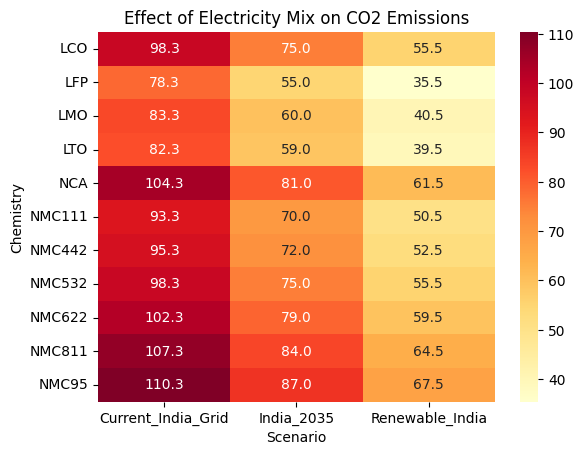

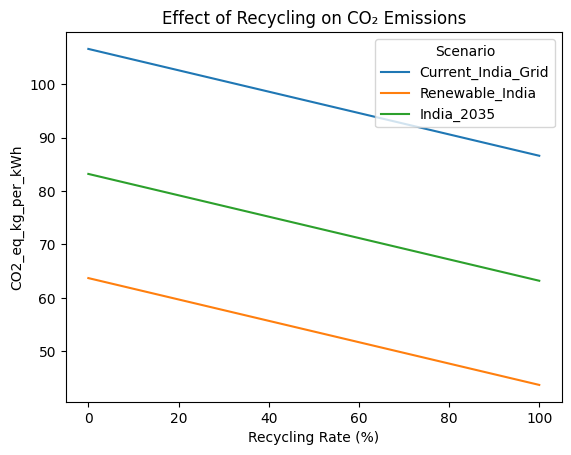

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
pivot = df.pivot_table(
    values='CO2-eq',
    index='Chemistry',
    columns='Scenario',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)

plt.title('Effect of Electricity Mix on CO2 Emissions')
plt.show()
plt.figure()
sns.lineplot(
    data=df,
    x='Recycling_Rate',
    y='CO2-eq',
    hue='Scenario',
    errorbar=None
)

plt.xlabel('Recycling Rate (%)')
plt.ylabel('CO2_eq_kg_per_kWh')
plt.title('Effect of Recycling on CO₂ Emissions')
plt.show()


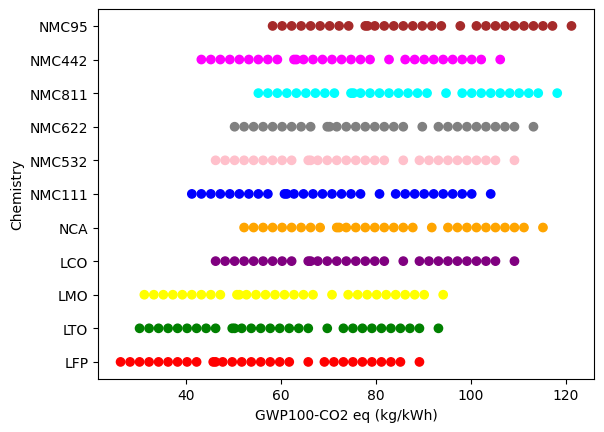

In [3]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}

plt.scatter(
    df['CO2-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('GWP100-CO2 eq (kg/kWh)')
plt.ylabel('Chemistry')
plt.show()

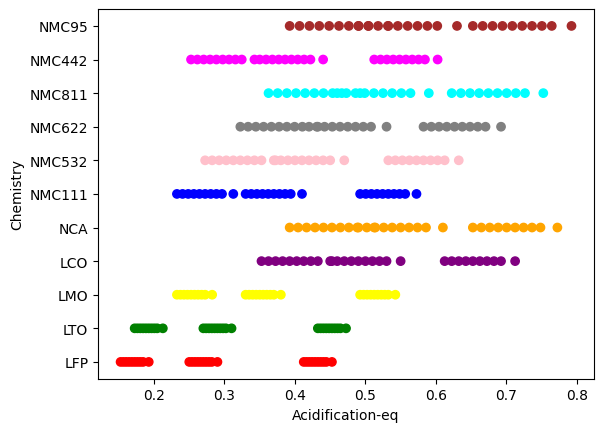

In [4]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}
plt.scatter(
    df['Acidification-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Acidification-eq')
plt.ylabel('Chemistry')
plt.show()

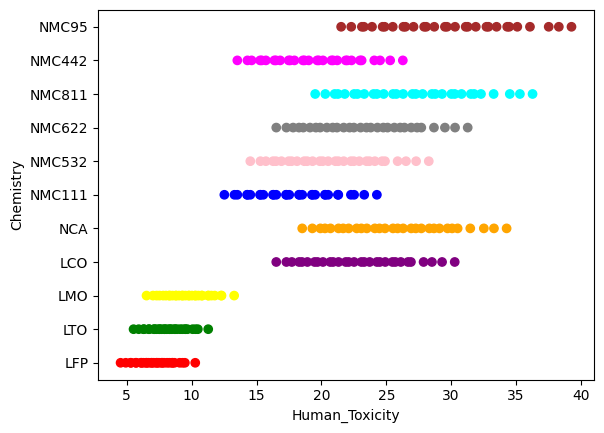

In [5]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}
plt.scatter(
    df['Human_Toxicity'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Human_Toxicity')
plt.ylabel('Chemistry')
plt.show()

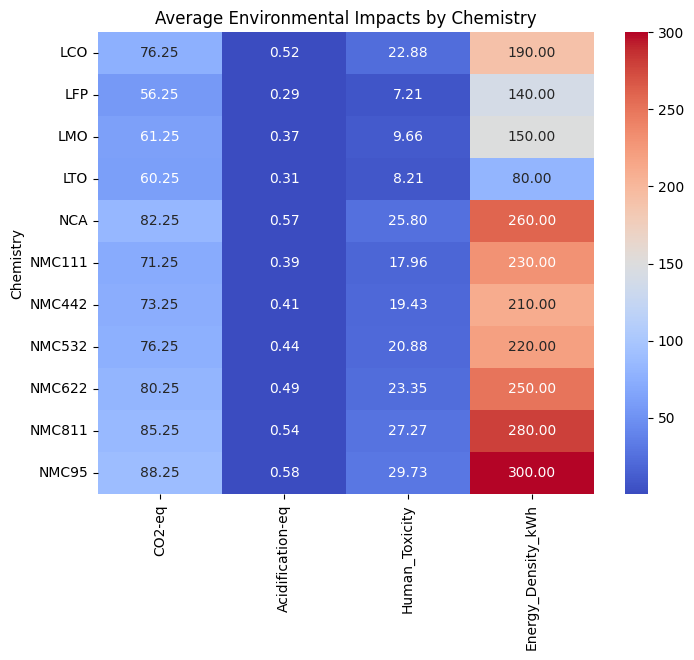

In [6]:
#plotting co2,acidification and htp graph together
import seaborn as sns
import matplotlib.pyplot as plt

avg_df = df.groupby('Chemistry')[
    [
        'CO2-eq',
        'Acidification-eq',
        'Human_Toxicity',
        'Energy_Density_kWh',
    ]
].mean()

plt.figure(figsize=(8,6))

sns.heatmap(
    avg_df,
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)

plt.title('Average Environmental Impacts by Chemistry')
plt.show()

In [7]:
#mathematical analysis from the data
df.describe()

,Recycling_Rate,Energy_Density_kWh,Material_Emission,Cell_Production_Emission,Base_Emission,Grid_Factor,Manufacturing_Emission,Recycling_Credit,CO2-eq,Base_Acidification,Acid_Grid_Factor,Manufacturing_Acidification,Acidification_Credit,Acidification-eq,Base_HTP,HTP_Grid_Factor,Manufacturing_HTP,HTP_Recycling_Credit,Human_Toxicity
count,330.00000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,54.00000,210.000000,44.727273,15.727273,60.454545,0.370000,24.050000,10.800000,73.704545,0.343636,0.002333,0.151667,0.049091,0.446212,23.636364,0.021000,1.365000,5.694545,19.306818
std,30.44353,62.908241,8.445328,1.765470,10.109104,0.270224,17.564592,6.088706,21.160841,0.113009,0.001652,0.107407,0.034588,0.146793,9.693849,0.011062,0.719039,4.112791,8.249458
min,0.00000,80.000000,30.000000,13.000000,43.000000,0.050000,3.250000,0.000000,26.250000,0.160000,0.000500,0.032500,0.000000,0.152500,8.000000,0.008000,0.520000,0.000000,4.520000
25%,30.00000,150.000000,34.000000,14.000000,48.000000,0.050000,3.250000,6.000000,57.750000,0.250000,0.000500,0.032500,0.024000,0.340625,11.000000,0.008000,0.520000,2.400000,11.275000
50%,55.00000,220.000000,47.000000,15.000000,63.000000,0.350000,22.750000,11.000000,73.450000,0.340000,0.002000,0.130000,0.040000,0.440500,26.000000,0.020000,1.300000,4.800000,20.275000
75%,80.00000,260.000000,52.000000,17.000000,69.000000,0.710000,46.150000,16.000000,89.750000,0.460000,0.004500,0.292500,0.072000,0.542500,32.000000,0.035000,2.275000,9.000000,25.250000
max,100.00000,300.000000,56.000000,19.000000,75.000000,0.710000,46.150000,20.000000,121.150000,0.500000,0.004500,0.292500,0.140000,0.792500,37.000000,0.035000,2.275000,16.000000,39.275000


Text(0.5, 0.5, 'GHG')

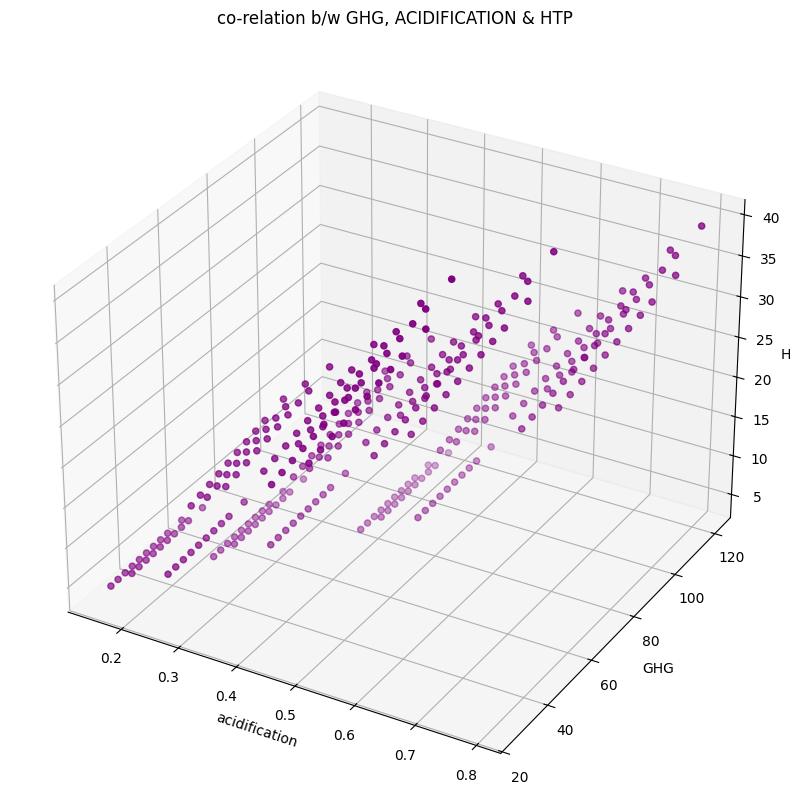

In [8]:
#3d plot to check relation b/w co2 nox/sox and htp
fig = plt.figure(figsize=(16,10))
ax= plt.subplot(projection='3d')
ax.scatter3D(df['Acidification-eq'],df['CO2-eq'],df['Human_Toxicity'],c='purple')
ax.set_title('co-relation b/w GHG, ACIDIFICATION & HTP')
ax.set_zlabel('HTP')
ax.set_xlabel('acidification')
ax.set_ylabel('GHG')

    Chemistry    CO2-eq  Acidification-eq  Human_Toxicity  Energy_Density_kWh
0         LFP  0.662803          0.468750        0.165588            0.272727
1         LFP  0.620653          0.456250        0.142569            0.272727
2         LFP  0.599579          0.450000        0.131060            0.272727
3         LFP  0.578504          0.443750        0.119551            0.272727
4         LFP  0.557429          0.437500        0.108042            0.272727
..        ...       ...               ...             ...                 ...
325     NMC95  0.626976          0.614844        0.695727            1.000000
326     NMC95  0.605901          0.592969        0.649691            1.000000
327     NMC95  0.584826          0.571094        0.603654            1.000000
328     NMC95  0.563751          0.549219        0.557618            1.000000
329     NMC95  0.542677          0.527344        0.511581            1.000000

[330 rows x 5 columns]


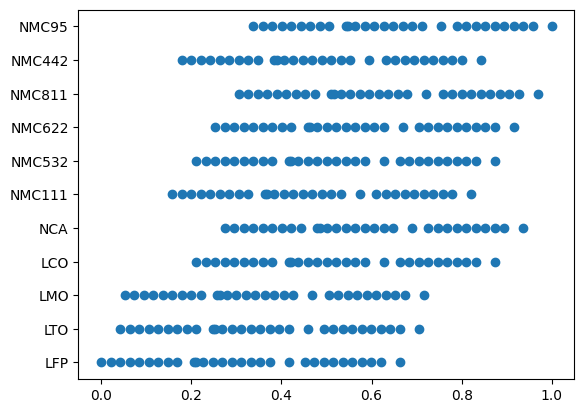

In [9]:
#EDA done to normalize the major colums and bring the value in range of 0-1 and perform better ml training'
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols = [
    'CO2-eq',
    'Acidification-eq',
    'Human_Toxicity',
    'Energy_Density_kWh'
]
df[cols] = scaler.fit_transform(df[cols])
print(df[[ 'Chemistry','CO2-eq',
    'Acidification-eq',
    'Human_Toxicity','Energy_Density_kWh']])
plt.scatter(df['CO2-eq'],df['Chemistry'])

In [17]:
#adding the sustainabilty,performance and cost column
df['sustainability_score'] =1-(df['Acidification-eq']+df['CO2-eq']+df['Human_Toxicity'])/3
df['performance_score'] = df['Energy_Density_kWh']
#cost score calculation data used:
#BatPaC (Argonne) → overall pack costs.
#CellEst 3.0 → chemistry-specific cell costs.
#Ciez & Whitacre (2019) → recycling economics.
#Harper et al. (2019) → recovered material value.
battery_cost = {
    'LFP':60,
    'LTO':90,
    'LMO':68,
    'LCO':82,
    'NCA':76,
    'NMC111':72,
    'NMC442':71,
    'NMC532':70,
    'NMC622':69,
    'NMC811':74,
    'NMC95':78
}
df['Battery_Cost'] = df['Chemistry'].map(battery_cost)
#High Ni/Co chemistries benefit more from recycling because valuable metals are recovered.
cost_credit = {
    'LFP':0.05,
    'LTO':0.03,
    'LMO':0.06,
    'LCO':0.15,
    'NCA':0.18,
    'NMC111':0.10,
    'NMC442':0.12,
    'NMC532':0.14,
    'NMC622':0.16,
    'NMC811':0.20,
    'NMC95':0.22
}
df['Cost_Credit'] = df['Chemistry'].map(cost_credit)
df['Adjusted_Cost'] = (
    df['Battery_Cost']
    *(1-df['Cost_Credit']*df['Recycling_Rate']/100)
)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['cost_score']] = scaler.fit_transform(
    df[['Adjusted_Cost']]
)
print(df[['sustainability_score','performance_score','cost_score']])

     sustainability_score  performance_score  cost_score
0                0.567620           0.272727    0.090909
1                0.593509           0.272727    0.072727
2                0.606454           0.272727    0.063636
3                0.619398           0.272727    0.054545
4                0.632343           0.272727    0.045455
..                    ...                ...         ...
325              0.354151           1.000000    0.324364
326              0.383813           1.000000    0.272364
327              0.413475           1.000000    0.220364
328              0.443137           1.000000    0.168364
329              0.472800           1.000000    0.116364

[330 rows x 3 columns]


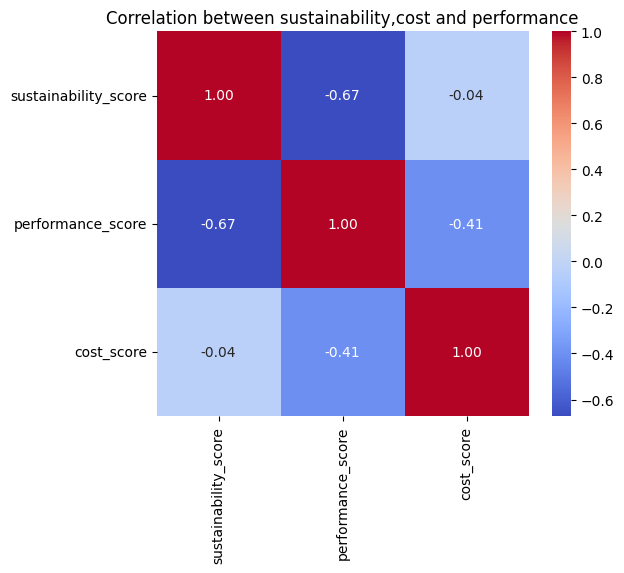

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sustainability_score','performance_score','cost_score'

]

plt.figure(figsize=(6,5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation between sustainability,cost and performance')
plt.show()